  * [The Unreasonable Effectiveness of Convolutional Neural Networks in Population Genetic Inference](https://www.google.com/search?q=https://academic.oup.com/mbe/article/36/2/220/5144577)
    Converts DNA sequences into black-and-white grids to visually detect evolutionary patterns.
  * [IGTD: Image Generation from Tabular Data for Advanced Machine Learning](https://www.nature.com/articles/s41598-021-90923-y)
    Rearranges flat spreadsheet features into a 2D matrix so CNN spatial filters can find hidden, non-linear correlations.
  * [Environmental Sound Classification with Convolutional Neural Networks](https://www.google.com/search?q=https://ieeexplore.ieee.org/document/7336915)
    Transforms 1D audio waves into visual Mel-Spectrogram heatmaps, allowing image models to classify sounds by "texture."
  * [Convolutional Neural Networks for Sentence Classification](https://arxiv.org/abs/1408.5882)
    Stacks word vector embeddings into a 2D sentence matrix and uses sliding filters to detect phrases.
  * [Crystal Graph Convolutional Neural Networks](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.120.145301)
    Uses a 3D graph structure to predict physical material properties based on atomic bonds.

# Convolutional Neural Networks in PyTorch

https://ezyang.github.io/convolution-visualizer/

https://adamharley.com/nn_vis/cnn/2d.html

**Prerequisites.** We assume `torch >= 2.0`, `torchvision`, `scikit-image`, and `matplotlib` are installed.

---

## Contents

0. Setup
1. Why CNNs
2. Data dimensionality: `NCHW`
3. Convolutional operations — `nn.Conv2d`, padding, stride, dilation
4. Spatial reduction & pooling
5. Normalization & regularization
6. Convolutions → classifications
7. Architectural patterns
8. Training a CNN on Fashion-MNIST


## 0. Setup

We'll use an image from `scikit-image` — a 512×512 grayscale photograph of a photographer.
Grayscale keeps the channel dimension simple (just 1).


In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

from skimage import data, transform as sk_transform

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.11.0
Using device: mps


Image tensor shape: (1, 1, 128, 128)
Pixel value range:  [0.01, 0.98]


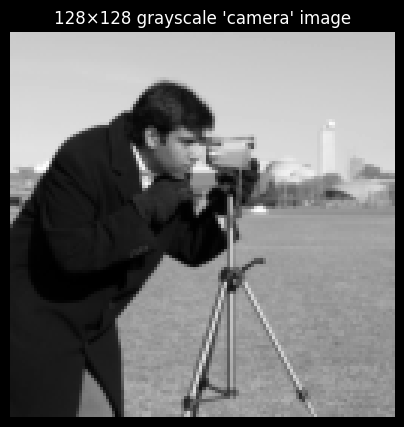

In [46]:
# Load the 'camera' sample image and resize to 128x128
img_np = data.camera().astype(np.float32) / 255.0             # normalize to [0, 1]
img_np = sk_transform.resize(img_np, (128, 128), anti_aliasing=True)

# Convert to a PyTorch tensor with shape [batch=1, channels=1, H=128, W=128]
img_tensor = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0)

print(f"Image tensor shape: {tuple(img_tensor.shape)}")
print(f"Pixel value range:  [{img_tensor.min():.2f}, {img_tensor.max():.2f}]")

plt.figure(figsize=(5, 5))
plt.imshow(img_np, cmap="gray")
plt.title("128×128 grayscale 'camera' image")
plt.axis("off")
plt.show()


## 1. The Limitation of Feed-Forward Networks (MLPs)

If we tried applying what we've learned so far (MLP) to the new data type (images), we'll encounter two problems

### Loss of spatial hierarchy
Flattening a 2-D image into a 1-D vector destroys correlations between adjacent pixels. CNN gives that "for free".

### Parameter count
Consider a 224×224 RGB image and a first hidden layer of just 1,000 neurons:

$$\text{Params} = (224 \times 224 \times 3) \times 1000 + 1000 = 150{,}529{,}000$$

That's **150 million parameters in a single layer**. Unreasonable and computationally wasteful.


In [9]:
class SimpleMLP(nn.Module):
    """A baseline fully-connected classifier. Expects 28x28 grayscale input."""
    def __init__(self, input_size=28*28, hidden_size=256, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: [batch, 1, 28, 28] -> flatten to [batch, 784]
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)                 # raw logits

mlp = SimpleMLP()
n_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"MLP parameter count: {n_params:,}")
print(f"Sanity-check forward pass: {mlp(torch.randn(4, 1, 28, 28)).shape}  (expected [4, 10])")


MLP parameter count: 269,322
Sanity-check forward pass: torch.Size([4, 10])  (expected [4, 10])


## 2. Data Dimensionality: The PyTorch `NCHW` Standard

**PyTorch expects images as 4-D tensors in `NCHW` format.**

$$\underbrace{N}_{\text{batch}} \;\times\; \underbrace{C}_{\text{channels}} \;\times\; \underbrace{H}_{\text{height}} \;\times\; \underbrace{W}_{\text{width}}$$

- **N (batch size):** how many images are processed in parallel.
- **C (channels):** 3 for RGB, 1 for grayscale. In deeper layers, this becomes the number of *feature maps* — each channel represents a different kernel.
- **H, W:** spatial dimensions.


In [10]:
# Single grayscale image, as you'd get from skimage / numpy
single = torch.randn(28, 28)
print("Raw (H, W):                  ", single.shape)

# Add channel and batch dims -> NCHW
batched = single.unsqueeze(0).unsqueeze(0)        # [1, 1, 28, 28]
print("NCHW for a single image:     ", batched.shape)

# A mini-batch of 16 Fashion-MNIST-sized images
batch = torch.randn(16, 1, 28, 28)
print("NCHW for a 16-image batch:   ", batch.shape)

# HWC -> CHW permute (common when loading RGB from PIL/NumPy)
hwc = torch.randn(28, 28, 3)
chw = hwc.permute(2, 0, 1)  # In .permute() we state the new dimensions in terms of the old dimensions

# Old dimensions : h - 0 , w - 1 , c - 2    -->
#
# New dimensions (permute inputs) : 2 (c) , 0 (h) , 1 (w)

print("After permute (C, H, W):     ", chw.shape)


Raw (H, W):                   torch.Size([28, 28])
NCHW for a single image:      torch.Size([1, 1, 28, 28])
NCHW for a 16-image batch:    torch.Size([16, 1, 28, 28])
After permute (C, H, W):      torch.Size([3, 28, 28])


Libraries like PIL, OpenCV, and Matplotlib use `HWC` (channels last). When you load images manually, you must `.permute()` into `NCHW`.

`torchvision.transforms.ToTensor()` does this conversion automatically.

Tensor Shape: (148, 148, 3)
Tensor Shape: torch.Size([3, 148, 148])


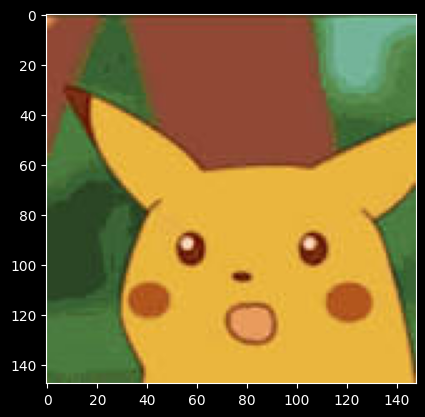

In [47]:
from PIL import Image
import matplotlib.pyplot as plt

raw_img = Image.open("example.jpeg")

img_array = np.array(raw_img)

# Check the dimensions
print(f"Tensor Shape: {img_array.shape}")

transform = torchvision.transforms.ToTensor()

img = transform(raw_img)

print(f"Tensor Shape: {img.shape}") # Expected: [C, H, W]

plt.imshow(img.permute(1, 2, 0))  # new Dims : 1 (H) , 2 (W), 0 (C)
plt.show()

## 3. Convolutional Operations: `nn.Conv2d`

https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

A convolution slides a small learnable **kernel** (a.k.a. *filter*) across the input, multiplying element-wise and summing at every position. The output is a **feature map** — a new image that lights up wherever the kernel's pattern is present.

In a trained CNN, thousands of these kernels are **learned** via backpropagation. But to build intuition, let's hand-craft one — a classic **Sobel vertical edge detector**:

$$K_{\text{vertical}} = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}$$

### Key arguments of `nn.Conv2d`

| Argument | Meaning |
|---|---|
| `in_channels` | Channels coming in (1 for grayscale, else `out_channels` of previous layer). |
| `out_channels` | Number of filters = number of feature maps produced. |
| `kernel_size` | Spatial size of each filter (e.g. `3` means 3×3). |
| `stride` | How many pixels the filter hops per step. Stride 2 halves H and W. |
| `padding` | Zeros added around the border. `padding=k//2` preserves H,W when stride=1. |
| `dilation` | Spacing inside the kernel — enlarges the *receptive field* without extra parameters. |

### Output-size formula (per spatial dimension)

$$H_\text{out} = \left\lfloor \frac{H_\text{in} + 2p - d(k-1) - 1}{s} \right\rfloor + 1$$

where $k$=kernel_size, $p$=padding, $s$=stride, $d$=dilation. You should be able to predict every output shape below before running the code.


### 3.1 Applying a kernel — Sobel edge detectors on the camera image

Input:       (1, 1, 128, 128)
Output:      (1, 1, 126, 126)   (H and W shrank by 2 -- no padding)


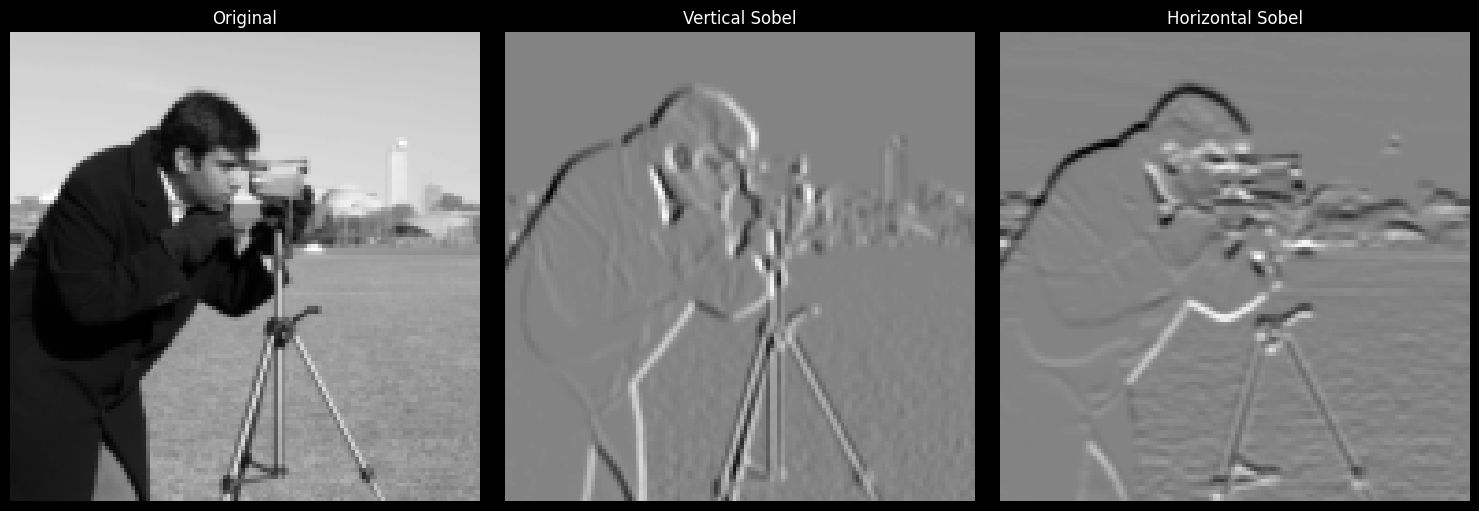

In [12]:
# Vertical and horizontal Sobel kernels, injected into Conv2d layers
sobel_v = torch.tensor([[[[-1., 0., 1.],
                          [-2., 0., 2.],
                          [-1., 0., 1.]]]])
sobel_h = torch.tensor([[[[-1., -2., -1.],
                          [ 0.,  0.,  0.],
                          [ 1.,  2.,  1.]]]])

conv_v = nn.Conv2d(1, 1, kernel_size=3, bias=False)
conv_h = nn.Conv2d(1, 1, kernel_size=3, bias=False)
with torch.no_grad():
    conv_v.weight.copy_(sobel_v)
    conv_h.weight.copy_(sobel_h)
    out_v = conv_v(img_tensor)
    out_h = conv_h(img_tensor)

print(f"Input:       {tuple(img_tensor.shape)}")
print(f"Output:      {tuple(out_v.shape)}   (H and W shrank by 2 -- no padding)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_tensor.squeeze().numpy(), cmap="gray"); axes[0].set_title("Original")
axes[1].imshow(out_v.squeeze().numpy(),     cmap="gray"); axes[1].set_title("Vertical Sobel")
axes[2].imshow(out_h.squeeze().numpy(),     cmap="gray"); axes[2].set_title("Horizontal Sobel")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()


Vertical structures — the tripod legs, the camera body — light up under the vertical filter, while horizontal bands of the coat and horizon line pop under the horizontal one. **The kernel is a learned feature detector.** A trained CNN discovers hundreds of these automatically.

### 3.2 Padding — keeping spatial dimensions fixed

A 128×128 input produced a **126×126** output — each 3×3 convolution "eats" one pixel off each border. **Padding** adds a border of zeros (or other values, see docs) around the image before convolving, so the output can match the input size.

For `kernel_size=3` with `stride=1`, use `padding=1` to preserve H and W.


Input                    : (1, 1, 128, 128)
Output WITHOUT padding   : (1, 1, 126, 126)   <- shrank by 2
Output WITH padding=1    : (1, 1, 128, 128)   <- preserved!


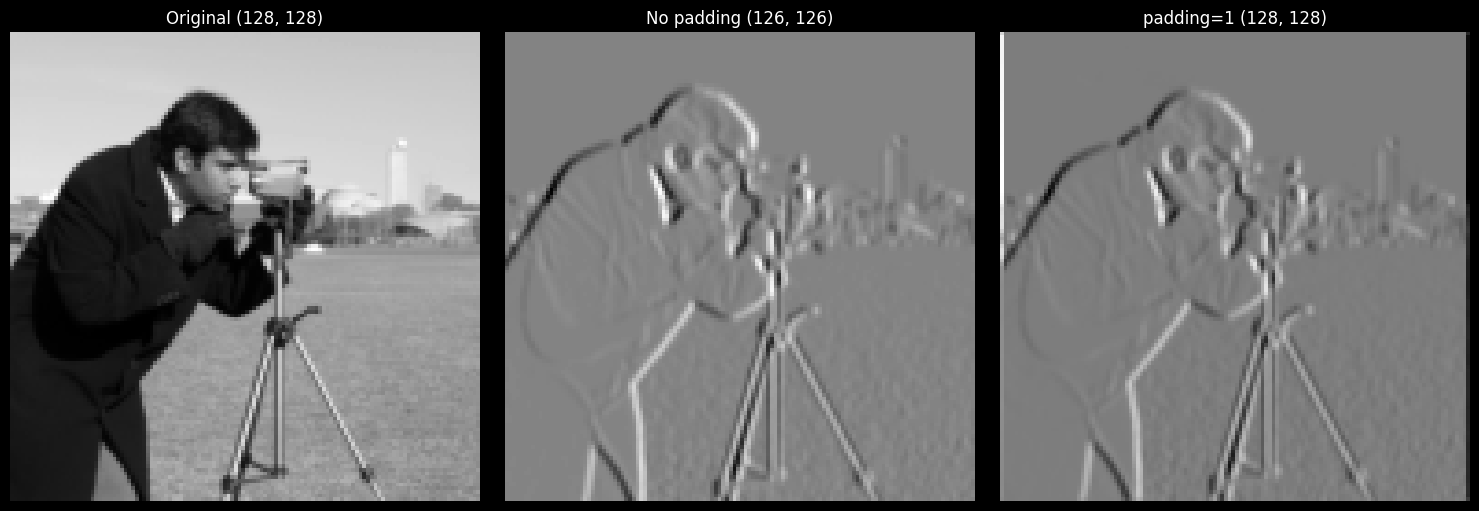

In [13]:
# Same vertical Sobel, now with padding=1 to preserve spatial dimensions
conv_padded = nn.Conv2d(1, 1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    conv_padded.weight.copy_(sobel_v)
    out_padded = conv_padded(img_tensor)

print(f"Input                    : {tuple(img_tensor.shape)}")
print(f"Output WITHOUT padding   : {tuple(out_v.shape)}   <- shrank by 2")
print(f"Output WITH padding=1    : {tuple(out_padded.shape)}   <- preserved!")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_tensor.squeeze().numpy(), cmap="gray")
axes[0].set_title(f"Original {tuple(img_tensor.shape[2:])}")
axes[1].imshow(out_v.squeeze().numpy(), cmap="gray")
axes[1].set_title(f"No padding {tuple(out_v.shape[2:])}")
axes[2].imshow(out_padded.squeeze().numpy(), cmap="gray")
axes[2].set_title(f"padding=1 {tuple(out_padded.shape[2:])}")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()


### 3.3 Stride — downsampling during convolution

**Stride** is how far the kernel jumps between positions. Stride 1 moves one pixel at a time (default). Stride 2 moves two pixels at a time — effectively **halving** output H and W.

Why stride? (1) **efficiency** — fewer output positions, (2) **larger receptive fields** in later layers, (3) **compression** — the network must pack information into fewer spatial locations.


Input:  (1, 1, 128, 128)   (H=W=128)
Output: (1, 1, 64, 64)    (H=W=64 -- dimensions halved)


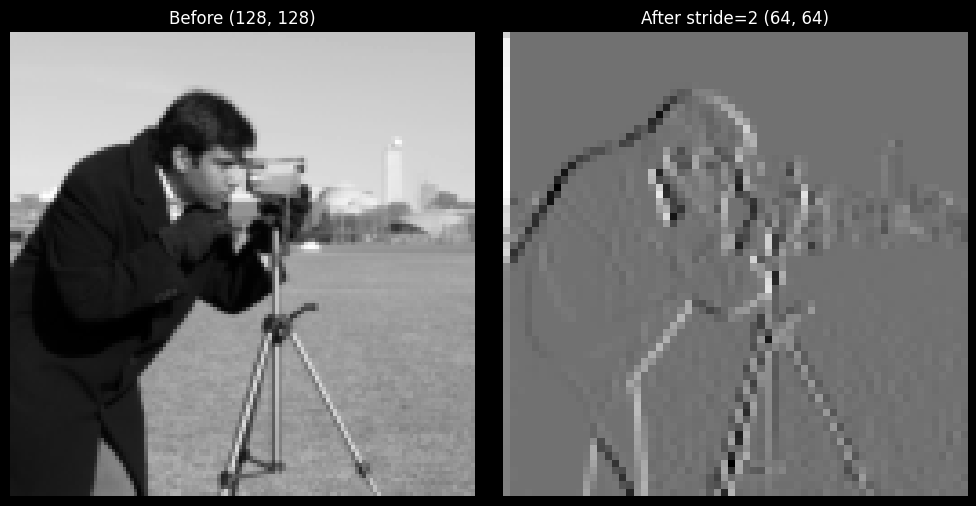

In [14]:
# Same Sobel kernel, but stride=2 halves both spatial dimensions
conv_stride = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1, bias=False)
with torch.no_grad():
    conv_stride.weight.copy_(sobel_v)
    out_stride = conv_stride(img_tensor)

# Formula check: (128 + 2*1 - 3)/2 + 1 = 64
print(f"Input:  {tuple(img_tensor.shape)}   (H=W=128)")
print(f"Output: {tuple(out_stride.shape)}    (H=W=64 -- dimensions halved)")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_tensor.squeeze().numpy(), cmap="gray")
axes[0].set_title(f"Before {tuple(img_tensor.shape[2:])}")
axes[1].imshow(out_stride.squeeze().numpy(), cmap="gray")
axes[1].set_title(f"After stride=2 {tuple(out_stride.shape[2:])}")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()


### 3.4 Dilation and the receptive field

**Dilation** inserts gaps inside the kernel. A dilated 3×3 kernel with `dilation=2` has the footprint of a 5×5 kernel but still only 9 parameters. This enlarges the **receptive field** — how much of the original image a single output neuron "sees" — without adding parameters or compute per position.

The *receptive field* grows naturally with depth too: two stacked 3×3 convs see a 5×5 input patch; three see 7×7. That's why depth matters for image understanding.


Input:               (1, 1, 128, 128)
Dilated output:      (1, 1, 128, 128)   (same H,W with padding=2)


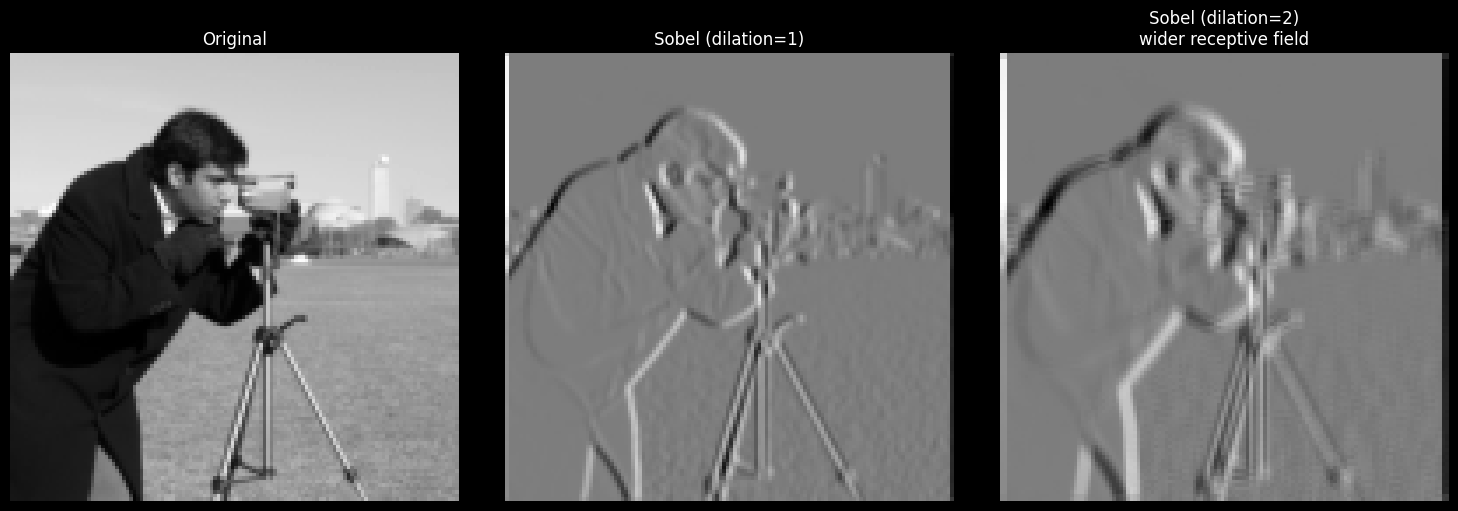


Conv2d(1,1,3) parameters: 9
Dilated conv parameters : 9
(Same parameter count -- dilation is free in terms of weights.)


In [15]:
conv_dilated = nn.Conv2d(1, 1, kernel_size=3, padding=2, dilation=2, bias=False)
with torch.no_grad():
    conv_dilated.weight.copy_(sobel_v)
    out_dilated = conv_dilated(img_tensor)

print(f"Input:               {tuple(img_tensor.shape)}")
print(f"Dilated output:      {tuple(out_dilated.shape)}   (same H,W with padding=2)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_tensor.squeeze().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[1].imshow(out_padded.squeeze().numpy(), cmap="gray")
axes[1].set_title("Sobel (dilation=1)")
axes[2].imshow(out_dilated.squeeze().numpy(), cmap="gray")
axes[2].set_title("Sobel (dilation=2)\nwider receptive field")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

# Parameter-count sanity check
print(f"\nConv2d(1,1,3) parameters: {sum(p.numel() for p in conv_padded.parameters())}")
print(f"Dilated conv parameters : {sum(p.numel() for p in conv_dilated.parameters())}")
print("(Same parameter count -- dilation is free in terms of weights.)")


## 4. Spatial Reduction & Pooling

Three things you'll actually use:

- **`nn.MaxPool2d`** — take the max in each window. Keeps the *strongest* activation.
- **`nn.AvgPool2d`** — take the mean. Smoother, less common in modern CNNs.
- **`nn.AdaptiveAvgPool2d`** — you specify the *output size* (e.g. `1×1`) and PyTorch picks the kernel/stride. Modern networks use this as the bridge from conv stack to classifier head.



Original:       (128, 128)
MaxPool x1:     (64, 64)
MaxPool x2:     (32, 32)
MaxPool x3:     (16, 16)


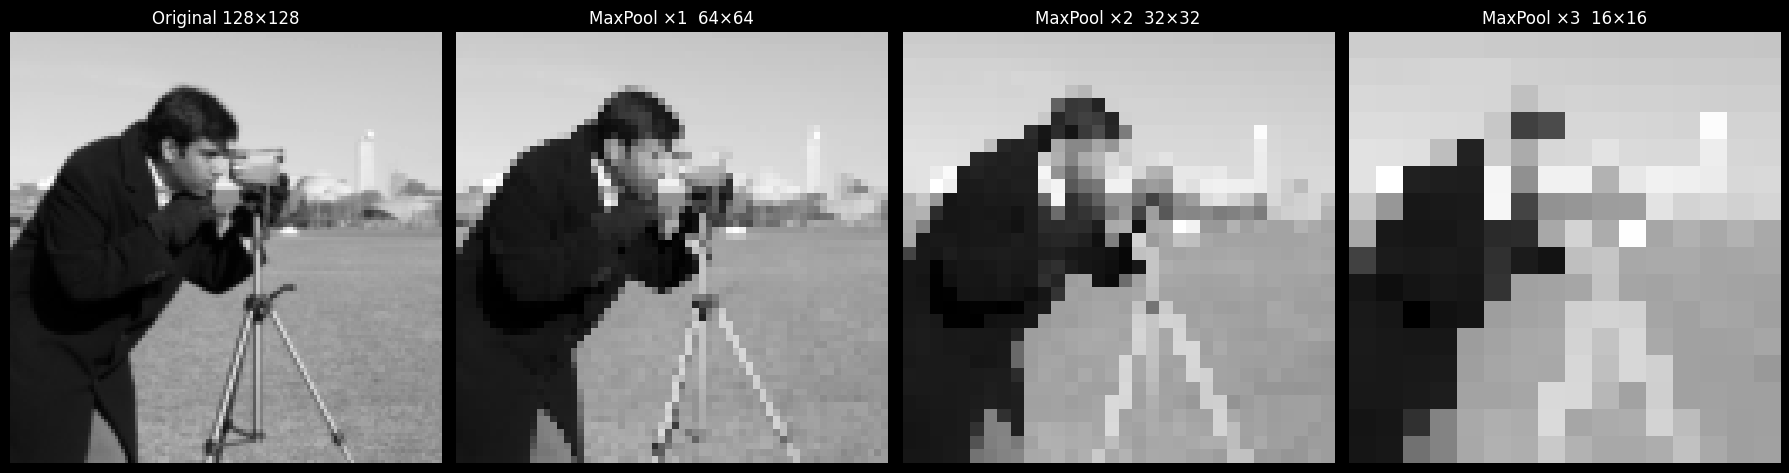

In [16]:
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

with torch.no_grad():
    mp1 = max_pool(img_tensor)        # 64x64
    mp2 = max_pool(mp1)               # 32x32
    mp3 = max_pool(mp2)               # 16x16
    ap1 = avg_pool(img_tensor)        # 64x64 -- for comparison

print(f"Original:       {tuple(img_tensor.shape[2:])}")
print(f"MaxPool x1:     {tuple(mp1.shape[2:])}")
print(f"MaxPool x2:     {tuple(mp2.shape[2:])}")
print(f"MaxPool x3:     {tuple(mp3.shape[2:])}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, t, title in zip(axes,
                        [img_tensor, mp1, mp2, mp3],
                        ["Original 128×128", "MaxPool ×1  64×64",
                         "MaxPool ×2  32×32", "MaxPool ×3  16×16"]):
    ax.imshow(t.squeeze().numpy(), cmap="gray"); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()


### Max vs. Average pooling side-by-side

MaxPool preserves the *strongest* response (crisper edges), AvgPool blurs (smoother, less detail). Compare them at the same output size.

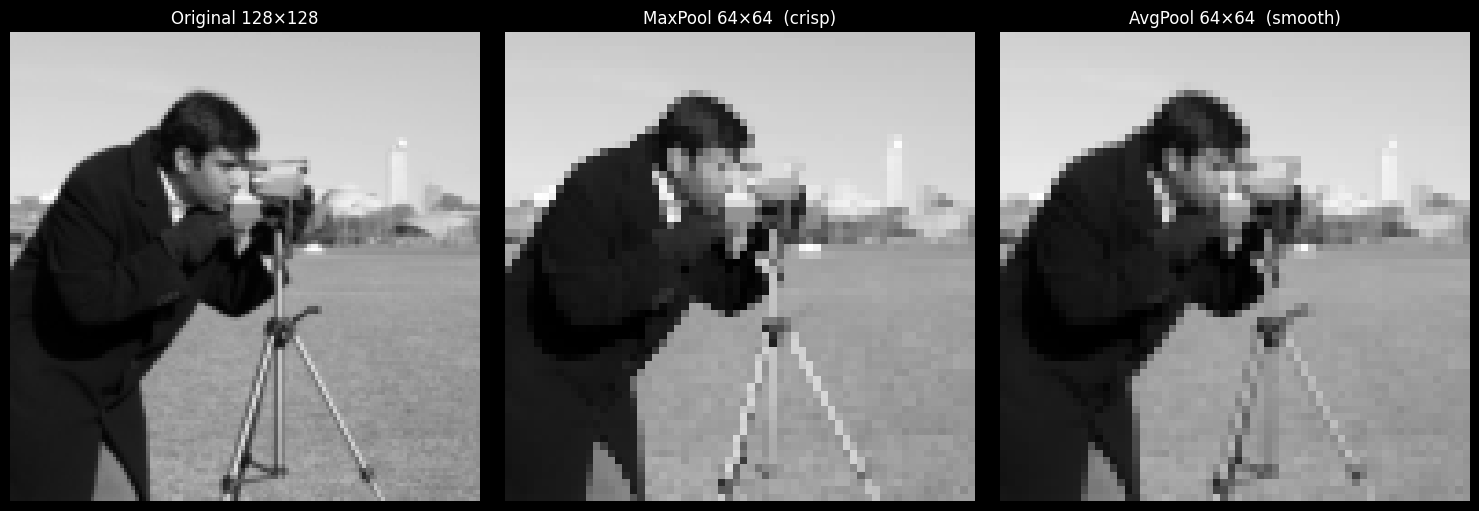

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_tensor.squeeze().numpy(), cmap="gray"); axes[0].set_title("Original 128×128")
axes[1].imshow(mp1.squeeze().numpy(),       cmap="gray"); axes[1].set_title("MaxPool 64×64  (crisp)")
axes[2].imshow(ap1.squeeze().numpy(),       cmap="gray"); axes[2].set_title("AvgPool 64×64  (smooth)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()


### Adaptive pooling — the modern classifier bridge

In [18]:
# AdaptiveAvgPool2d: specify the OUTPUT size, not the kernel
gap = nn.AdaptiveAvgPool2d(output_size=1)         # global average pooling
print("Global Average Pool output:", gap(img_tensor).shape)  # [1, 1, 1, 1]

# Works on any input size -- that's the whole point
for h, w in [(28, 28), (128, 128), (37, 41)]:
    x = torch.randn(1, 16, h, w)
    print(f"Input {(h,w)}  ->  GAP output {tuple(gap(x).shape)}")


Global Average Pool output: torch.Size([1, 1, 1, 1])
Input (28, 28)  ->  GAP output (1, 16, 1, 1)
Input (128, 128)  ->  GAP output (1, 16, 1, 1)
Input (37, 41)  ->  GAP output (1, 16, 1, 1)


## 5. Normalization & Regularization

### 5.1 Input normalization — what it actually does to an image

Before any conv is applied, we typically normalize inputs to zero mean and unit variance (using per-channel statistics for the dataset). This keeps gradients well-scaled and speeds up training.

Let's see what normalization does to a real image *as a distribution of pixel values* — the image "looks" almost the same, but its histogram is recentered and rescaled, and that's what matters to the network.


Original -> mean=0.506, std=0.282, range=[0.01, 0.98]
Normalized -> mean=-0.000, std=1.000, range=[-1.75, 1.69]


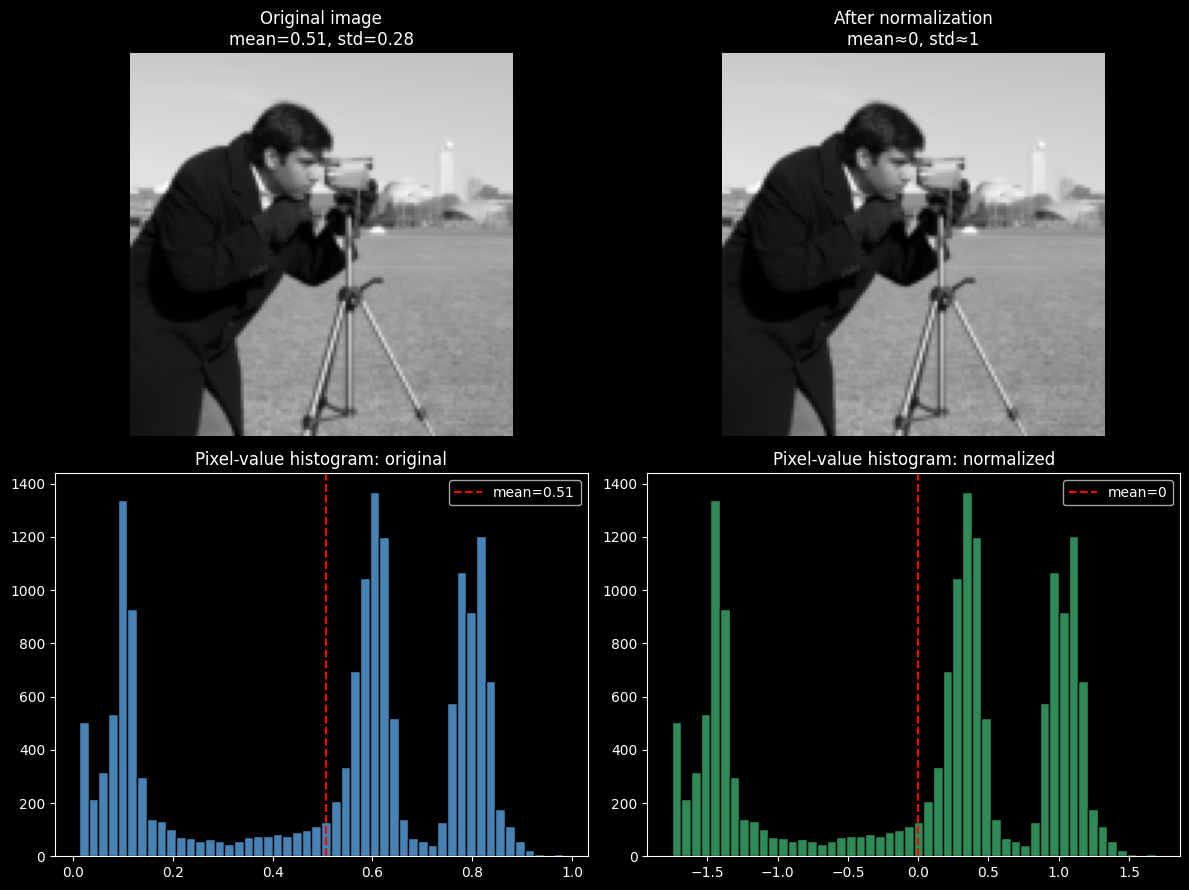

In [19]:
# Compute camera-image statistics and normalize
mean = img_tensor.mean().item()
std  = img_tensor.std().item()
print(f"Original -> mean={mean:.3f}, std={std:.3f}, range=[{img_tensor.min():.2f}, {img_tensor.max():.2f}]")

normalized = (img_tensor - mean) / std
print(f"Normalized -> mean={normalized.mean():.3f}, std={normalized.std():.3f}, "
      f"range=[{normalized.min():.2f}, {normalized.max():.2f}]")

# Visualize: the image (rescaled for display) + histograms before/after
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0,0].imshow(img_tensor.squeeze().numpy(), cmap="gray")
axes[0,0].set_title(f"Original image\nmean={mean:.2f}, std={std:.2f}"); axes[0,0].axis("off")
axes[0,1].imshow(normalized.squeeze().numpy(), cmap="gray")
axes[0,1].set_title(f"After normalization\nmean≈0, std≈1"); axes[0,1].axis("off")

axes[1,0].hist(img_tensor.numpy().ravel(), bins=50, color="steelblue", edgecolor="k")
axes[1,0].axvline(mean, color="red", ls="--", label=f"mean={mean:.2f}")
axes[1,0].set_title("Pixel-value histogram: original"); axes[1,0].legend()
axes[1,1].hist(normalized.numpy().ravel(), bins=50, color="seagreen", edgecolor="k")
axes[1,1].axvline(0, color="red", ls="--", label="mean=0")
axes[1,1].set_title("Pixel-value histogram: normalized"); axes[1,1].legend()
plt.tight_layout(); plt.show()


### 5.2 Batch Normalization (`nn.BatchNorm2d`)

For each channel, BatchNorm normalizes activations across the batch to have mean 0 and variance 1, then applies a learnable affine transform. Effects: higher stable learning rates, faster convergence, mild regularization.

BatchNorm behaves differently in train vs. eval:
- **`model.train()`** — uses *current batch* statistics, updates running averages.
- **`model.eval()`**  — uses *stored running averages* (so outputs don't depend on batch composition).

Let's visualize BN applied to *feature maps* produced by a Sobel filter on the camera image.


Before BN, per-channel (mean, std):
  channel 0: mean=+3.03, std=2.43
  channel 1: mean=+2.96, std=2.31
  channel 2: mean=+3.00, std=0.52
  channel 3: mean=+3.09, std=0.89

After BN, per-channel (mean, std):  # should be ~0, ~1 per channel
  channel 0: mean=-0.00, std=1.00
  channel 1: mean=-0.00, std=1.00
  channel 2: mean=+0.00, std=1.00
  channel 3: mean=+0.00, std=1.00


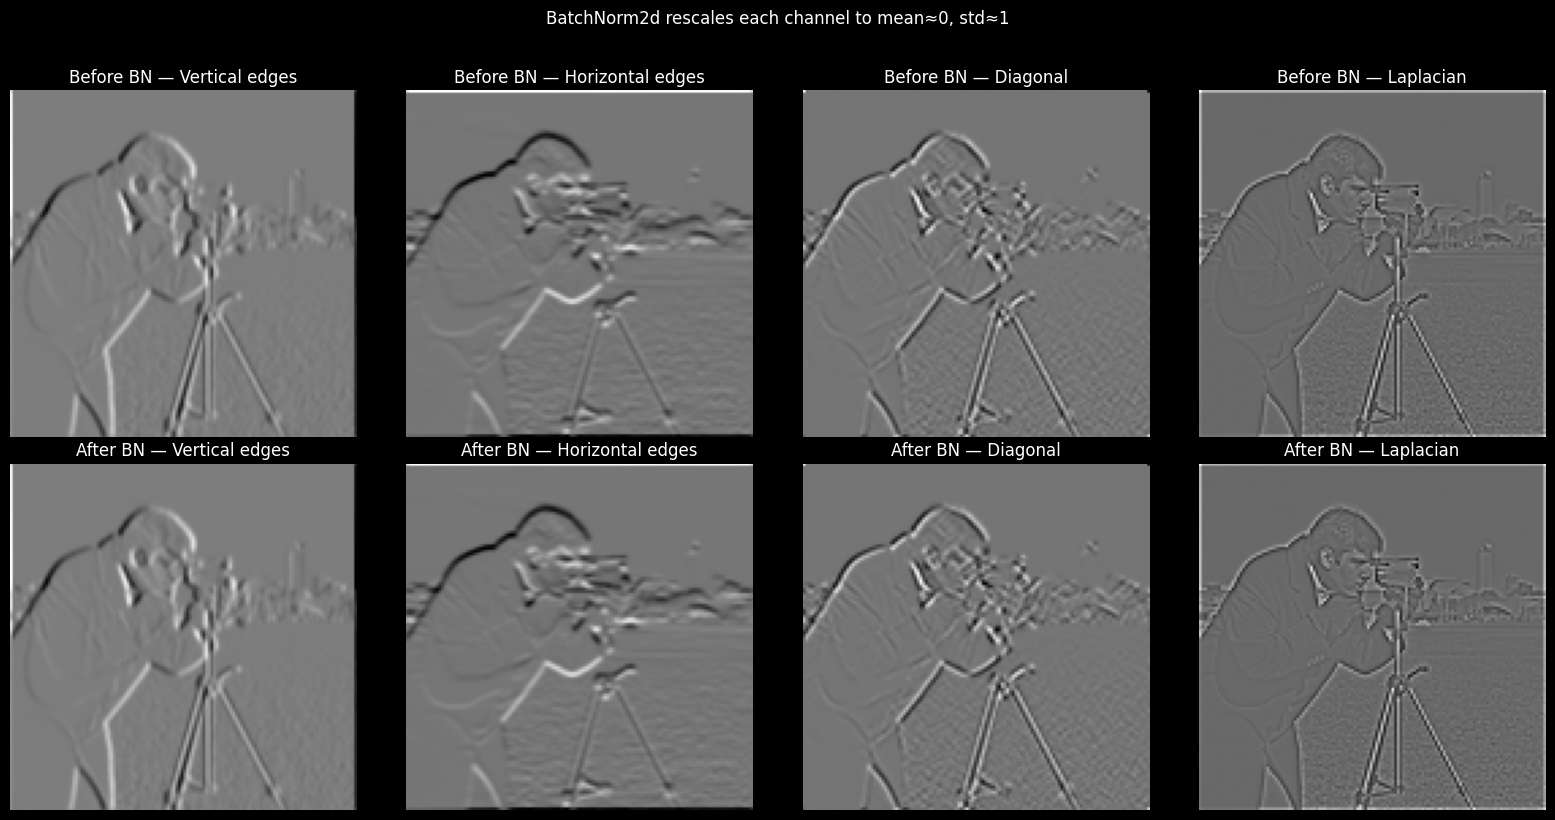

In [20]:
# Step 1: produce feature maps with 4 edge-like kernels
conv4 = nn.Conv2d(1, 4, kernel_size=3, padding=1, bias=False)
kernels = torch.stack([
    sobel_v.squeeze(0),                           # vertical
    sobel_h.squeeze(0),                           # horizontal
    torch.tensor([[[1., 0., -1.], [0., 0., 0.], [-1., 0., 1.]]]),   # diag
    torch.tensor([[[0.,-1., 0.], [-1., 4.,-1.], [0.,-1., 0.]]]),    # Laplacian
])
with torch.no_grad():
    conv4.weight.copy_(kernels)
    feat = conv4(img_tensor)                      # [1, 4, 128, 128]

# Pretend the feature maps were produced at a wildly non-standard scale
feat_shifted = feat * 5.0 + 3.0                   # mean ~3, std ~5

# Step 2: apply BatchNorm2d(4) in training mode
bn = nn.BatchNorm2d(num_features=4)
bn.train()
feat_bn = bn(feat_shifted)

# Per-channel stats before/after (channel-wise; that's how BN operates)
def per_channel_stats(t):
    return [(t[0, c].mean().item(), t[0, c].std().item()) for c in range(t.shape[1])]

print("Before BN, per-channel (mean, std):")
for c, (m, s) in enumerate(per_channel_stats(feat_shifted)): print(f"  channel {c}: mean={m:+.2f}, std={s:.2f}")
print("\nAfter BN, per-channel (mean, std):  # should be ~0, ~1 per channel")
for c, (m, s) in enumerate(per_channel_stats(feat_bn)):      print(f"  channel {c}: mean={m:+.2f}, std={s:.2f}")

# Step 3: visualize one channel's feature map before and after BN
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
titles = ["Vertical edges", "Horizontal edges", "Diagonal", "Laplacian"]
for c in range(4):
    axes[0, c].imshow(feat_shifted[0, c].detach().numpy(), cmap="gray")
    axes[0, c].set_title(f"Before BN — {titles[c]}"); axes[0, c].axis("off")
    axes[1, c].imshow(feat_bn[0, c].detach().numpy(), cmap="gray")
    axes[1, c].set_title(f"After BN — {titles[c]}"); axes[1, c].axis("off")
plt.suptitle("BatchNorm2d rescales each channel to mean≈0, std≈1", y=1.02)
plt.tight_layout(); plt.show()


### 5.3 Dropout

https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout2d.html

`nn.Dropout2d` randomly zeroes out entire *channels* during training (a spatial generalization of plain dropout). It forces the network to distribute information across many feature maps instead of relying on any single one. Active in `train()`, identity in `eval()`.


In [21]:
dropout = nn.Dropout2d(p=0.25)

# 100 dummy feature maps of all-ones to measure the fraction zeroed
x = torch.ones(1, 100, 1, 1)

dropout.train()
z_train = dropout(x)
print(f"Dropout2d in train() mode, fraction of zeroed channels: {(z_train == 0).float().mean():.2f} (~0.25 expected)")

dropout.eval()
z_eval = dropout(x)
print(f"Dropout2d in eval()  mode, fraction of zeroed channels: {(z_eval == 0).float().mean():.2f} (should be 0)")

# Apply channel-wise dropout to our camera feature maps and show one "surviving" vs "dropped" channel pair
dropout.train()
feat_drop = dropout(feat)
print("\nChannel means after dropout:")
for c in range(4):
    print(f"  channel {c}: mean={feat_drop[0, c].mean().item():+.3f}")


Dropout2d in train() mode, fraction of zeroed channels: 0.29 (~0.25 expected)
Dropout2d in eval()  mode, fraction of zeroed channels: 0.00 (should be 0)

Channel means after dropout (zero means the channel was dropped this call):
  channel 0: mean=+0.009
  channel 1: mean=-0.012
  channel 2: mean=+0.000
  channel 3: mean=+0.024


## 6. Convolutions → Classifications

Your convolutional stack outputs 4-D feature maps `[N, C, H, W]`. Your loss function wants 2-D logits `[N, num_classes]`. Two standard bridges:

**Option A — Flatten + Linear (classic).** `nn.Flatten` collapses `(C, H, W)` into a feature vector of length `C·H·W`, then `nn.Linear` projects to class logits. You must know the exact feature count — a frequent source of shape-mismatch errors.

**Option B — Global Average Pooling + Linear (modern, preferred).** Use `nn.AdaptiveAvgPool2d(1)` to reduce every feature map to a single number, then `nn.Linear(C, num_classes)`. Far fewer parameters, better generalization, input-size-agnostic.


In [22]:
feat = torch.randn(4, 64, 7, 7)     # pretend conv stack output

# Option A: Flatten + Linear
flatten = nn.Flatten()
classifier_A = nn.Linear(64 * 7 * 7, 10)
print("Option A (Flatten + Linear):")
print(f"  flat shape:   {flatten(feat).shape}")
print(f"  logits shape: {classifier_A(flatten(feat)).shape}")
print(f"  # params in head: {sum(p.numel() for p in classifier_A.parameters()):,}")

# Option B: GAP + Linear
gap = nn.AdaptiveAvgPool2d(1)
classifier_B = nn.Linear(64, 10)
print("\nOption B (GAP + Linear):")
print(f"  pooled shape: {gap(feat).shape}")
print(f"  logits shape: {classifier_B(gap(feat).flatten(1)).shape}")
print(f"  # params in head: {sum(p.numel() for p in classifier_B.parameters()):,}")


Option A (Flatten + Linear):
  flat shape:   torch.Size([4, 3136])
  logits shape: torch.Size([4, 10])
  # params in head: 31,370

Option B (GAP + Linear):
  pooled shape: torch.Size([4, 64, 1, 1])
  logits shape: torch.Size([4, 10])
  # params in head: 650


## 7. Modern Architectural Patterns

Vanilla conv → conv stacks work, but every modern CNN (ResNet, EfficientNet, ConvNeXt, MobileNet, …) uses a handful of structural tricks.

### 7.1 Residual connections
Instead of learning $H(x)$ directly, learn the *residual* $F(x)$ and output $F(x) + x$. The identity path gives gradients a direct highway backward — this is what enables 50+, 100+, even 1000+ layer networks to train.

### 7.2 Bottleneck blocks
A 1×1 conv shrinks the channel count, a 3×3 conv does the real spatial work in the reduced space, and a final 1×1 conv expands back out. Small accuracy cost, large compute saving.

### 7.3 Depthwise separable convolutions
Split a standard conv into two cheaper pieces: a **depthwise** conv (one kernel per input channel) + a **pointwise** 1×1 conv (cross-channel mixing). This is the backbone of MobileNet and related mobile/edge architectures.

Below we build a residual block, run the camera image through it (with untrained random weights — the block acts as a generic spatial mixer), and visualize its feature maps.


Residual block: (1, 8, 128, 128) -> (1, 8, 128, 128)   (shape preserved)


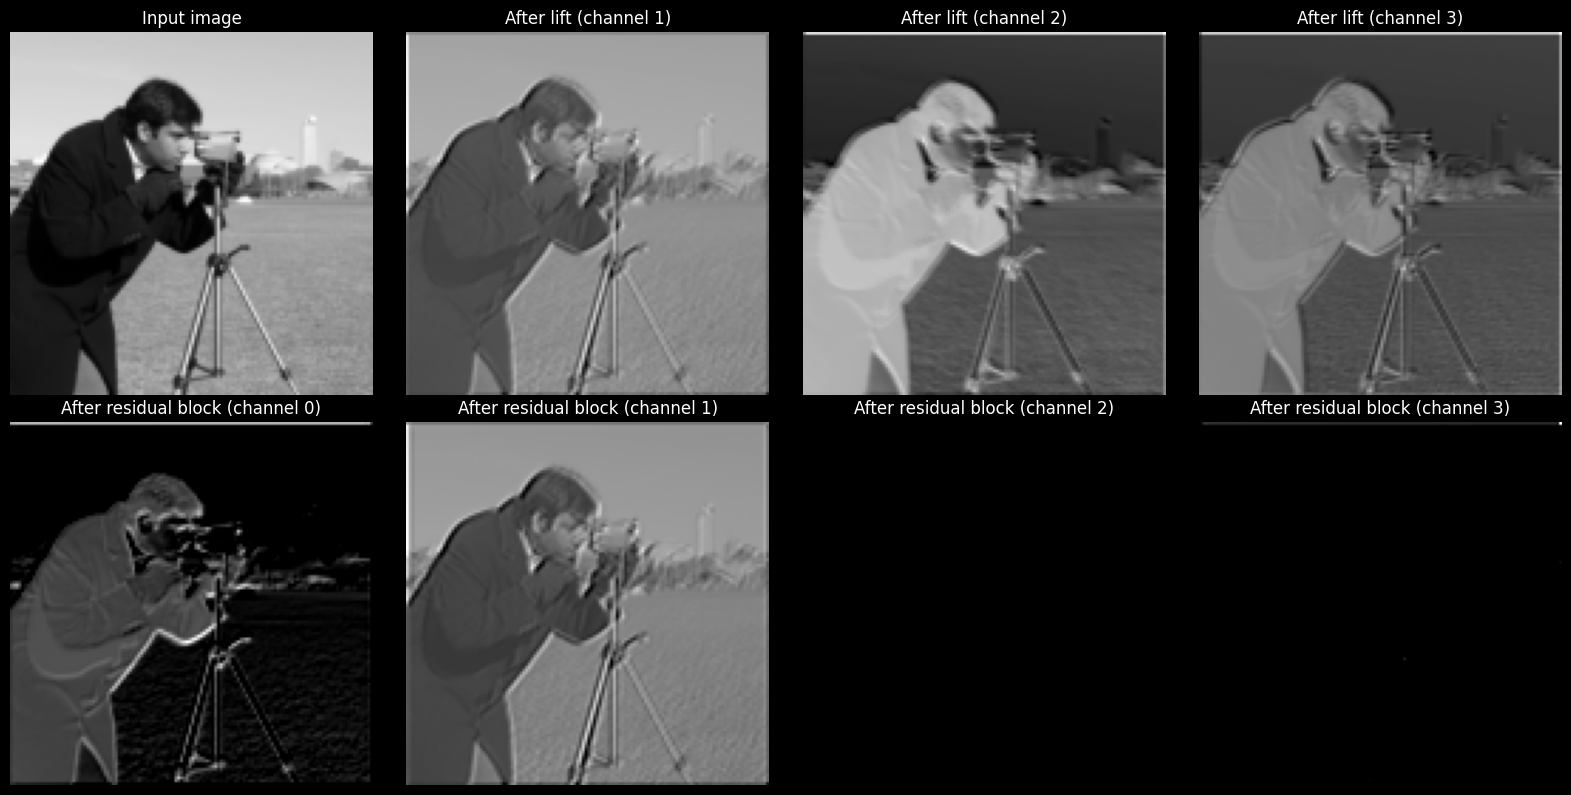

In [23]:
class BasicResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + identity)          # <-- the residual connection

# Lift our 1-channel image to 8 channels so the residual block has something interesting to work with
lift = nn.Conv2d(1, 8, kernel_size=3, padding=1)
block = BasicResidualBlock(channels=8)
block.eval()
with torch.no_grad():
    x = lift(img_tensor)                       # [1, 8, 128, 128]
    y = block(x)                               # [1, 8, 128, 128]
print(f"Residual block: {tuple(x.shape)} -> {tuple(y.shape)}   (shape preserved)")

# Visualize 4 of the 8 output feature maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(img_tensor.squeeze().numpy(), cmap="gray"); axes[0, 0].set_title("Input image"); axes[0, 0].axis("off")
for c in range(1, 4):
    axes[0, c].imshow(x[0, c].detach().numpy(), cmap="gray")
    axes[0, c].set_title(f"After lift (channel {c})"); axes[0, c].axis("off")
for c in range(4):
    axes[1, c].imshow(y[0, c].detach().numpy(), cmap="gray")
    axes[1, c].set_title(f"After residual block (channel {c})"); axes[1, c].axis("off")
plt.tight_layout(); plt.show()


## 8. Full Pipeline: Training on Fashion-MNIST (MLP vs CNN)

Time to assemble the pieces and race an MLP against a CNN on **Fashion-MNIST** — 10 clothing categories, 28×28 grayscale, 60k train / 10k test images.

The standard PyTorch training loop has five parts:

1. A `Dataset` that knows how to load one example.
2. A `DataLoader` that batches and shuffles.
3. A model subclassing `nn.Module` with a `forward()` method.
4. A loss function and optimizer.
5. The loop itself, with `model.train()` / `model.eval()` at the right times.


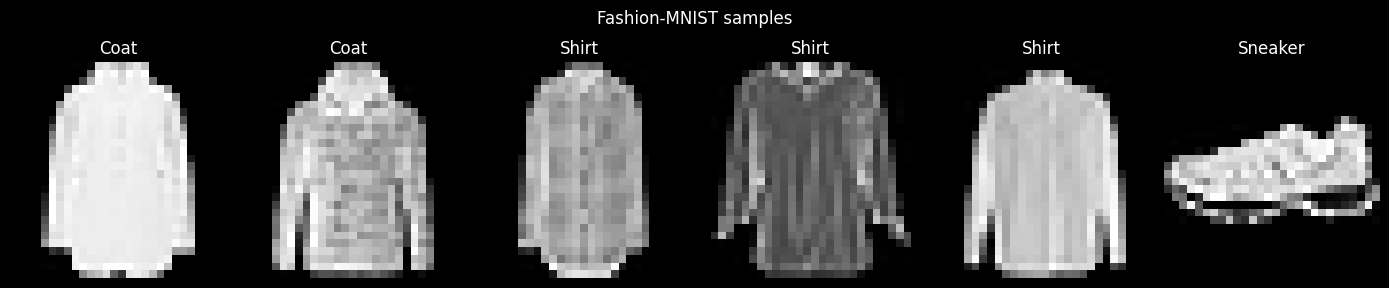

In [24]:
# 8.1 Load Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),   # published FashionMNIST stats
])

train_set = torchvision.datasets.FashionMNIST(root="./data", train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)

class_names = ["T-shirt","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Boot"]

examples, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(examples[i].squeeze().numpy(), cmap="gray")
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.suptitle("Fashion-MNIST samples")
plt.tight_layout(); plt.show()


### Why odd-sized kernels?

Odd kernel sizes (1, 3, 5, 7) are nearly universal in CNNs. A few compelling reasons:

**1. A well-defined center pixel.** An odd kernel $k \times k$ has a unique center at position $(\lfloor k/2 \rfloor, \lfloor k/2 \rfloor)$. Every output pixel corresponds to one input pixel that the kernel is "centered on" — the feature map stays spatially aligned with the input. A $2 \times 2$ or $4 \times 4$ kernel has no true center; its reference point falls between pixels, introducing a half-pixel shift between input and output.

**2. Symmetric padding is possible.** To preserve spatial dimensions with stride 1, the output-size formula requires:

$$p = \frac{k - 1}{2}$$

This is an integer only when $k$ is odd. For $k = 3$, padding $p = 1$ adds one row/column on *each* side — symmetric. For $k = 4$, you'd need $p = 1.5$, forcing asymmetric padding (1 on one side, 2 on the other), which biases the spatial response.

**3. Symmetric receptive field.** An odd kernel looks the same number of pixels left and right, up and down, from its center. This matters because natural image features (edges, corners, textures) have no inherent directional bias — an even kernel would systematically see more context on one side than the other.

**4. Stacking math works cleanly.** Two $3 \times 3$ convs have the same receptive field as one $5 \times 5$, with fewer parameters ($2 \cdot 9 = 18$ vs $25$) and an extra nonlinearity. This decomposition-into-small-odd-kernels pattern — the basis of VGG, ResNet, and almost every modern architecture — only produces clean receptive-field arithmetic when every kernel is odd.

In [34]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        # Stage 1: 28x28 -> 14x14
        self.stage1 = nn.Sequential(
            nn.Conv2d(1,  64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        # Stage 2: 14x14 -> 7x7
        self.stage2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.dropout = nn.Dropout2d(p=0.25)  ## Dropout2D zeros ENTIRE CHANNELS randomly - similar to "turning off" neurons
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.dropout(x)
        x = self.gap(x).flatten(1)      # [N, 64, 1, 1] -> [N, 64]
        return self.fc(x)

# cnn = SmallCNN()
print(f"CNN parameter count: {sum(p.numel() for p in cnn.parameters()):,}")
print(f"Forward-pass sanity: {cnn(torch.randn(4, 1, 28, 28)).shape}  (expected [4, 10])")


CNN parameter count: 112,330
Forward-pass sanity: torch.Size([4, 10])  (expected [4, 10])


### Parameter count (per layer)

**Conv2d:**

$$N_\text{conv} = (k_h \cdot k_w \cdot C_\text{in} \cdot C_\text{out}) + C_\text{out}$$

Drop the $+C_\text{out}$ bias term when `bias=False` (standard when followed by BatchNorm).

**BatchNorm2d:**

$$N_\text{bn} = 2 \cdot C$$

Learnable: scale $\gamma$ and shift $\beta$ per channel. Running mean and variance are buffers, not parameters.

**Linear:**

$$N_\text{fc} = (F_\text{in} \cdot F_\text{out}) + F_\text{out}$$

### BatchNorm2d forward pass

For a mini-batch of activations $x$ with shape $(N, C, H, W)$, for each channel $c$:

$$\mathbb{E}[x_c] = \frac{1}{N \cdot H \cdot W} \sum_{n,h,w} x_{n,c,h,w}$$

$$\text{Var}[x_c] = \frac{1}{N \cdot H \cdot W} \sum_{n,h,w} (x_{n,c,h,w} - \mathbb{E}[x_c])^2$$

$$\hat{x}_{n,c,h,w} = \frac{x_{n,c,h,w} - \mathbb{E}[x_c]}{\sqrt{\text{Var}[x_c] + \epsilon}}$$

$$y_{n,c,h,w} = \gamma_c \cdot \hat{x}_{n,c,h,w} + \beta_c$$

Only $\gamma_c$ and $\beta_c$ are learned. Statistics $\mathbb{E}[x_c]$ and $\text{Var}[x_c]$ are computed from the batch during training, and replaced by running averages at inference.

### 8.3 A shared training / evaluation loop

One function trains any `nn.Module`.

Practical notes you should internalize:
- Call `model.train()` before training and `model.eval()` before evaluation.
- Wrap validation in `torch.no_grad()` — skips autograd graph construction.
- `optimizer.zero_grad()` *before* `loss.backward()` — gradients accumulate otherwise.


In [48]:
from ptflops import get_model_complexity_info
macs, params = get_model_complexity_info(
    cnn, (1, 28, 28), as_strings=True,
    print_per_layer_stat=True, verbose=True
)

print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
print('{:<30}  {:<8}'.format('Number of parameters: ', params))

SmallCNN(
  112.33 k, 100.000% Params, 44.25 MMac, 99.570% MACs, 
  (stage1): Sequential(
    37.7 k, 33.558% Params, 29.7 MMac, 66.844% MACs, 
    (0): Conv2d(576, 0.513% Params, 451.58 KMac, 1.016% MACs, 1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, 0.114% Params, 100.35 KMac, 0.226% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(0, 0.000% Params, 50.18 KMac, 0.113% MACs, inplace=True)
    (3): Conv2d(36.86 k, 32.818% Params, 28.9 MMac, 65.038% MACs, 64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, 0.114% Params, 100.35 KMac, 0.226% MACs, 64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(0, 0.000% Params, 50.18 KMac, 0.113% MACs, inplace=True)
    (6): MaxPool2d(0, 0.000% Params, 50.18 KMac, 0.113% MACs, kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (stage2): Sequential(
    73.98 k, 65.863%

In [35]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(dim=1) == y).sum().item()
        total   += y.size(0)
    return correct / total

def train_model(model, epochs=3, lr=1e-3, name="model"):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    val_accs = []
    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0); seen += x.size(0)
        val_acc = evaluate(model, test_loader)
        val_accs.append(val_acc)
        print(f"[{name}] epoch {epoch}/{epochs}  train_loss={running/seen:.4f}  val_acc={val_acc*100:.2f}%")
    return val_accs


### 8.4 Train the MLP

In [38]:
EPOCHS = 5

mlp_model = SimpleMLP()
print(f"MLP parameters: {sum(p.numel() for p in mlp_model.parameters()):,}\n")
mlp_accs = train_model(mlp_model, epochs=EPOCHS, name="MLP")


MLP parameters: 269,322

[MLP] epoch 1/5  train_loss=0.4736  val_acc=84.36%
[MLP] epoch 2/5  train_loss=0.3449  val_acc=86.02%
[MLP] epoch 3/5  train_loss=0.3067  val_acc=87.33%
[MLP] epoch 4/5  train_loss=0.2836  val_acc=87.84%
[MLP] epoch 5/5  train_loss=0.2624  val_acc=87.51%


### 8.5 Train the CNN

In [39]:
cnn_model = SmallCNN()
print(f"CNN parameters: {sum(p.numel() for p in cnn_model.parameters()):,}\n")
cnn_accs = train_model(cnn_model, epochs=EPOCHS, name="CNN")


CNN parameters: 112,330

[CNN] epoch 1/5  train_loss=0.7171  val_acc=81.85%
[CNN] epoch 2/5  train_loss=0.4190  val_acc=86.48%
[CNN] epoch 3/5  train_loss=0.3553  val_acc=88.77%
[CNN] epoch 4/5  train_loss=0.3198  val_acc=88.49%
[CNN] epoch 5/5  train_loss=0.2939  val_acc=89.70%


### 8.6 Compare parameters and accuracy

Model        Parameters       Final Val Acc
-------------------------------------------------------
MLP             269,322              87.51%
CNN             112,330              89.70%


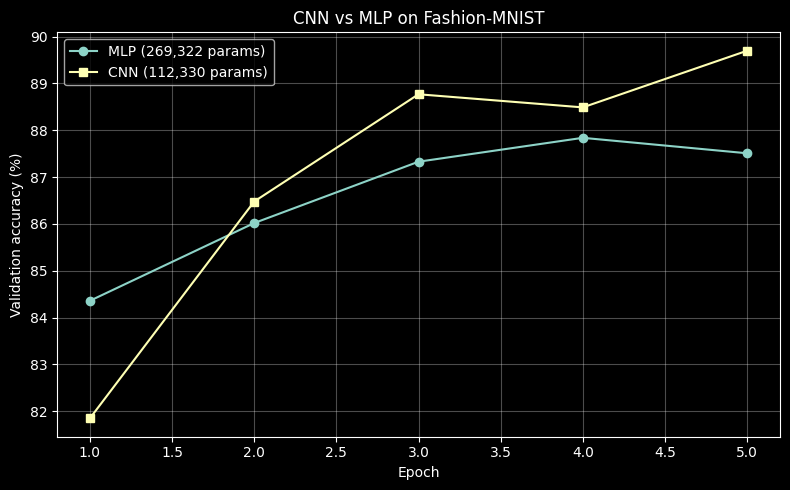

In [42]:
mlp_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print("="*55)
print(f'{"Model":<8}{"Parameters":>15}{"Final Val Acc":>20}')
print("-"*55)
print(f'{"MLP":<8}{mlp_params:>15,}{mlp_accs[-1]*100:>19.2f}%')
print(f'{"CNN":<8}{cnn_params:>15,}{cnn_accs[-1]*100:>19.2f}%')
print("="*55)

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS+1), [a*100 for a in mlp_accs], "o-", label=f"MLP ({mlp_params:,} params)")
plt.plot(range(1, EPOCHS+1), [a*100 for a in cnn_accs], "s-", label=f"CNN ({cnn_params:,} params)")
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy (%)")
plt.title("CNN vs MLP on Fashion-MNIST")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 8.7 CNN predictions on test images

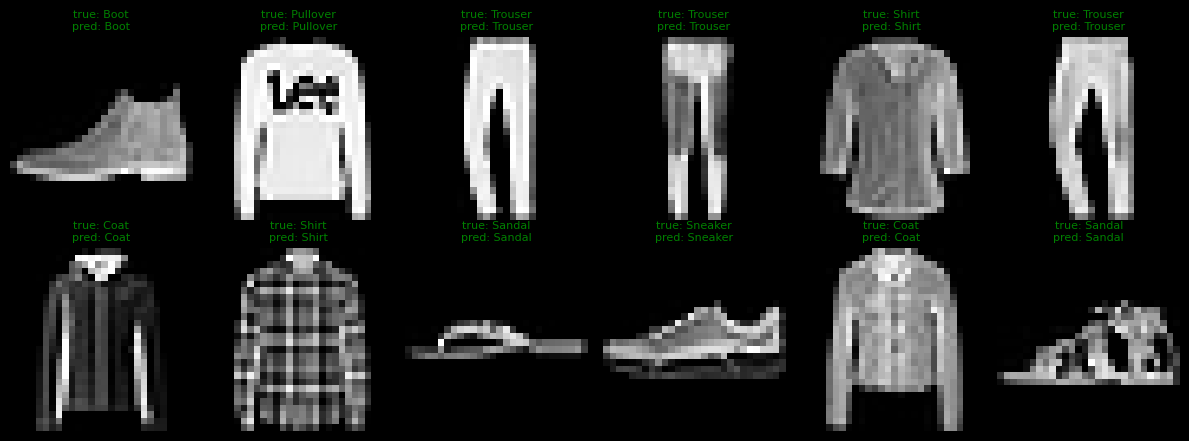

In [49]:
cnn_model.eval()
x, y = next(iter(test_loader))
with torch.no_grad():
    preds = cnn_model(x.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for ax, img, true_lbl, pred_lbl in zip(axes.flat, x[:12], y[:12], preds[:12]):
    ax.imshow(img.squeeze(), cmap="gray")
    ok = (true_lbl.item() == pred_lbl.item())
    color = "green" if ok else "red"
    ax.set_title(f"true: {class_names[true_lbl]}\npred: {class_names[pred_lbl]}",
                 fontsize=8, color=color)
    ax.axis("off")
plt.tight_layout(); plt.show()
